In [0]:
!pip install kagglehub[pandas-datasets]>=0.3.8

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# Análisis de Factores que Afectan el Precio de Vehículos Usados (CarDekho Dataset)

**Objetivo:**  
Analizar qué factores influyen en el precio de los autos usados en la India utilizando PySpark, Pandas y SQL.  
Se trabajará con el dataset de [CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho), que contiene información sobre marca, modelo, año, kilometraje, tipo de combustible y precio.

**Herramientas utilizadas:**  
- Databricks (entorno de trabajo)  
- PySpark (procesamiento distribuido de datos)  
- Pandas (análisis exploratorio detallado)  
- SQL (consultas y combinaciones entre tablas)


## Importación de librerías

En esta sección se importan las librerías necesarias para el análisis.  
- **Pandas y NumPy:** análisis exploratorio y manejo de datos tabulares.  
- **PySpark:** procesamiento distribuido y consultas SQL sobre grandes volúmenes de datos.  
- **Matplotlib y Seaborn:** visualización de resultados.  
- **KaggleHub:** descarga de datasets desde Kaggle.

In [0]:
# Librerías principales
import pandas as pd                
import numpy as np                 
from pyspark.sql import SparkSession   
from pyspark.sql import functions as F  
import os

# Visualización 
import matplotlib.pyplot as plt
import seaborn as sns

# Librería para descargar datasets 
import kagglehub

In [0]:
import kagglehub

# Descargar el dataset
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")
print(f"Dataset descargado en: {path}")


Dataset descargado en: /home/spark-c6bbc5c4-84aa-4061-8840-24/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4


## Carga del dataset desde Kaggle usando funciones personalizadas

Para automatizar la descarga y lectura del dataset, se implementaron tres funciones:
1. `download_dataset_zip()` — descarga el dataset desde Kaggle.
2. `extract_zip_files()` — detecta y extrae los archivos CSV.
3. `create_csv()` — carga el CSV en un DataFrame de Pandas.

Finalmente, el DataFrame se convierte a PySpark para continuar con el análisis distribuido.


In [0]:
def download_dataset_zip(url = "https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho"):
        print("Descargando dataset desde Kaggle...")
        dataset_path = kagglehub.dataset_download(url)
        print("Ruta al dataset:", dataset_path)
        return dataset_path
    
def extract_zip_files(dataset_path):
        zip_files = [f for f in os.listdir(dataset_path) if f.endswith('.zip')]
        if zip_files:
            zip_file = os.path.join(dataset_path, zip_files[0])
            extract_dir = os.path.join(dataset_path, "extracted")
            os.makedirs(extract_dir, exist_ok=True)
            print(f"Extrayendo {zip_file} en {extract_dir}...")
            with zipfile.ZipFile(zip_file, "r") as z:
                z.extractall(extract_dir)
            return extract_dir
        else:
            # Si no se encuentra un ZIP, se verifica si existen archivos CSV en la ruta
            csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
            if csv_files:
                print("No se encontró archivo ZIP pero se detectaron archivos CSV; se asume que el dataset ya se encuentra extraído.")
                return dataset_path
            else:
                raise FileNotFoundError("No se encontró ningún archivo .zip ni archivos .csv en la ruta del dataset")

def create_csv(csv_dir):
        #os.makedirs('src/static/csv', exist_ok=True)
        csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]
        if not csv_files:
            raise FileNotFoundError("No se encontraron archivos CSV en el directorio extraído")

        for file in csv_files:
            file_path = os.path.join(csv_dir, file)
            print(f"Leyendo {file_path}...")
            try:
                df = pd.read_csv(file_path, encoding="latin1")
            except Exception as e:
                print(f"Error al leer {file}: {e}")
                continue
            print(f"Creando/actualizando ")
        print("cvs creado correctamente en ")
        return df


In [0]:
# 1. Descargar el dataset desde Kaggle
dataset_path = download_dataset_zip("nehalbirla/vehicle-dataset-from-cardekho")

# 2. Extraer los archivos (o detectar CSV)
csv_dir = extract_zip_files(dataset_path)

# 3. Crear el DataFrame de Pandas
df_pd = create_csv(csv_dir)

# 4. Mostrar las primeras filas
df_pd.head()


Descargando dataset desde Kaggle...
Ruta al dataset: /home/spark-c6bbc5c4-84aa-4061-8840-24/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4
No se encontró archivo ZIP pero se detectaron archivos CSV; se asume que el dataset ya se encuentra extraído.
Leyendo /home/spark-c6bbc5c4-84aa-4061-8840-24/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/car details v4.csv...
Creando/actualizando 
Leyendo /home/spark-c6bbc5c4-84aa-4061-8840-24/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/CAR DETAILS FROM CAR DEKHO.csv...
Creando/actualizando 
Leyendo /home/spark-c6bbc5c4-84aa-4061-8840-24/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/car data.csv...
Creando/actualizando 
Leyendo /home/spark-c6bbc5c4-84aa-4061-8840-24/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/Car details v3.csv...
Creando/actualizando 
cvs creado correctamente en 


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [0]:
# Convertir DataFrame de Pandas a Spark
df = spark.createDataFrame(df_pd)

# Mostrar estructura y primeras filas
df.printSchema()
df.show(5)


root
 |-- name: string (nullable = true)
 |-- year: long (nullable = true)
 |-- selling_price: long (nullable = true)
 |-- km_driven: long (nullable = true)
 |-- fuel: string (nullable = true)
 |-- seller_type: string (nullable = true)
 |-- transmission: string (nullable = true)
 |-- owner: string (nullable = true)
 |-- mileage: string (nullable = true)
 |-- engine: string (nullable = true)
 |-- max_power: string (nullable = true)
 |-- torque: string (nullable = true)
 |-- seats: double (nullable = true)

+--------------------+----+-------------+---------+------+-----------+------------+------------+----------+-------+----------+--------------------+-----+
|                name|year|selling_price|km_driven|  fuel|seller_type|transmission|       owner|   mileage| engine| max_power|              torque|seats|
+--------------------+----+-------------+---------+------+-----------+------------+------------+----------+-------+----------+--------------------+-----+
|Maruti Swift Dzir...|2014|

In [0]:
# Tabla 1: autos
cars = df.select("name", "year", "km_driven", "selling_price", "fuel", "transmission")

# Tabla 2: vendedores
sellers = df.select("name", "seller_type", "owner")

# Mostrar primeras filas
print("Tabla de autos:")
cars.show(5)

print("Tabla de vendedores:")
sellers.show(5)


Tabla de autos:
+--------------------+----+---------+-------------+------+------------+
|                name|year|km_driven|selling_price|  fuel|transmission|
+--------------------+----+---------+-------------+------+------------+
|Maruti Swift Dzir...|2014|   145500|       450000|Diesel|      Manual|
|Skoda Rapid 1.5 T...|2014|   120000|       370000|Diesel|      Manual|
|Honda City 2017-2...|2006|   140000|       158000|Petrol|      Manual|
|Hyundai i20 Sport...|2010|   127000|       225000|Diesel|      Manual|
|Maruti Swift VXI ...|2007|   120000|       130000|Petrol|      Manual|
+--------------------+----+---------+-------------+------+------------+
only showing top 5 rows
Tabla de vendedores:
+--------------------+-----------+------------+
|                name|seller_type|       owner|
+--------------------+-----------+------------+
|Maruti Swift Dzir...| Individual| First Owner|
|Skoda Rapid 1.5 T...| Individual|Second Owner|
|Honda City 2017-2...| Individual| Third Owner|
|Hy

In [0]:
cars.createOrReplaceTempView("cars")
sellers.createOrReplaceTempView("sellers")


In [0]:
%sql
-- Precio promedio por tipo de vendedor
SELECT s.seller_type, AVG(c.selling_price) AS avg_price
FROM sellers s
JOIN cars c ON s.name = c.name
GROUP BY s.seller_type


seller_type,avg_price
Individual,451554.05879054026
Dealer,2194887.082537059
Trustmark Dealer,764608.1654639827


In [0]:
spark.sql("""
    SELECT s.seller_type, AVG(c.selling_price) AS avg_price
    FROM sellers s
    JOIN cars c ON s.name = c.name
    GROUP BY s.seller_type
""").show()


+----------------+------------------+
|     seller_type|         avg_price|
+----------------+------------------+
|      Individual|451554.05879054026|
|          Dealer| 2194887.082537059|
|Trustmark Dealer| 764608.1654639827|
+----------------+------------------+



In [0]:
# Tabla de autos
cars = df.select("name", "year", "km_driven", "selling_price", "fuel", "transmission")

# Tabla de vendedores
sellers = df.select("name", "seller_type", "owner")

print("Tabla de autos:")
cars.show(5)

print("Tabla de vendedores:")
sellers.show(5)


Tabla de autos:
+--------------------+----+---------+-------------+------+------------+
|                name|year|km_driven|selling_price|  fuel|transmission|
+--------------------+----+---------+-------------+------+------------+
|Maruti Swift Dzir...|2014|   145500|       450000|Diesel|      Manual|
|Skoda Rapid 1.5 T...|2014|   120000|       370000|Diesel|      Manual|
|Honda City 2017-2...|2006|   140000|       158000|Petrol|      Manual|
|Hyundai i20 Sport...|2010|   127000|       225000|Diesel|      Manual|
|Maruti Swift VXI ...|2007|   120000|       130000|Petrol|      Manual|
+--------------------+----+---------+-------------+------+------------+
only showing top 5 rows
Tabla de vendedores:
+--------------------+-----------+------------+
|                name|seller_type|       owner|
+--------------------+-----------+------------+
|Maruti Swift Dzir...| Individual| First Owner|
|Skoda Rapid 1.5 T...| Individual|Second Owner|
|Honda City 2017-2...| Individual| Third Owner|
|Hy

## Creación de bases de datos relacionadas

A partir del dataset original de CarDekho se generaron dos tablas:

- **cars:** información técnica del vehículo (`name`, `year`, `km_driven`, `selling_price`, `fuel`, `transmission`).
- **sellers:** información del vendedor (`name`, `seller_type`, `owner`).

Ambas se relacionan mediante la columna `name`, que identifica cada modelo de vehículo.

Esto permite realizar consultas SQL conjuntas para analizar los factores que influyen en el precio.


In [0]:
resultado = spark.sql("""
SELECT 
    s.seller_type,
    ROUND(AVG(c.selling_price), 2) AS avg_price,
    COUNT(c.name) AS total_autos
FROM sellers s
JOIN cars c ON s.name = c.name
GROUP BY s.seller_type
ORDER BY avg_price DESC
""")

resultado.show()


+----------------+----------+-----------+
|     seller_type| avg_price|total_autos|
+----------------+----------+-----------+
|          Dealer|2194887.08|      19361|
|Trustmark Dealer| 764608.17|       7899|
|      Individual| 451554.06|     105204|
+----------------+----------+-----------+



/home/spark-c6bbc5c4-84aa-4061-8840-24/.ipykernel/5773/command-5267679530703987-321358292:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultado_pd, x="seller_type", y="avg_price", palette="coolwarm")


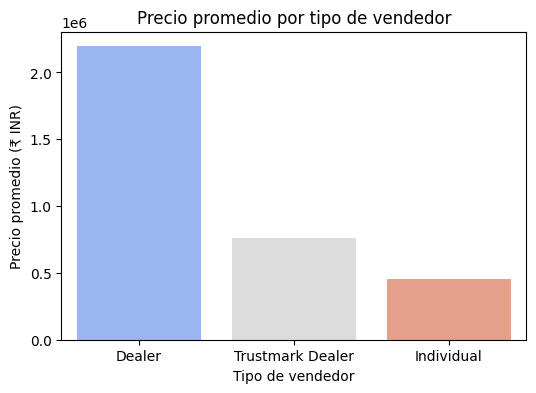

In [0]:
resultado_pd = resultado.toPandas()

plt.figure(figsize=(6,4))
sns.barplot(data=resultado_pd, x="seller_type", y="avg_price", palette="coolwarm")
plt.title("Precio promedio por tipo de vendedor")
plt.xlabel("Tipo de vendedor")
plt.ylabel("Precio promedio (₹ INR)")
plt.show()


## Conclusión

Del análisis se observa que el **tipo de vendedor** y el **tipo de combustible**
son factores relevantes en el precio de los autos usados.  
Los autos vendidos por distribuidores suelen tener precios promedio más altos,
mientras que los vehículos con combustible diésel presentan un valor ligeramente inferior.
